In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/dirty_cafe_sales.csv")
print("First 5 rows:")
print(df.head())

First 5 rows:
  Transaction ID    Item Quantity Price Per Unit Total Spent  Payment Method  \
0    TXN_1961373  Coffee        2            2.0         4.0     Credit Card   
1    TXN_4977031    Cake        4            3.0        12.0            Cash   
2    TXN_4271903  Cookie        4            1.0       ERROR     Credit Card   
3    TXN_7034554   Salad        2            5.0        10.0         UNKNOWN   
4    TXN_3160411  Coffee        2            2.0         4.0  Digital Wallet   

   Location Transaction Date  
0  Takeaway       2023-09-08  
1  In-store       2023-05-16  
2  In-store       2023-07-19  
3   UNKNOWN       2023-04-27  
4  In-store       2023-06-11  


In [3]:
print("\nLast 5 rows:")
print(df.tail())


Last 5 rows:
     Transaction ID      Item Quantity Price Per Unit Total Spent  \
9995    TXN_7672686    Coffee        2            2.0         4.0   
9996    TXN_9659401       NaN        3            NaN         3.0   
9997    TXN_5255387    Coffee        4            2.0         8.0   
9998    TXN_7695629    Cookie        3            NaN         3.0   
9999    TXN_6170729  Sandwich        3            4.0        12.0   

      Payment Method  Location Transaction Date  
9995             NaN   UNKNOWN       2023-08-30  
9996  Digital Wallet       NaN       2023-06-02  
9997  Digital Wallet       NaN       2023-03-02  
9998  Digital Wallet       NaN       2023-12-02  
9999            Cash  In-store       2023-11-07  


In [4]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB
None


In [5]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
       Transaction ID   Item Quantity Price Per Unit Total Spent  \
count           10000   9667     9862           9821        9827   
unique          10000     10        7              8          19   
top       TXN_9226047  Juice        5            3.0         6.0   
freq                1   1171     2013           2429         979   

        Payment Method  Location Transaction Date  
count             7421      6735             9841  
unique               5         4              367  
top     Digital Wallet  Takeaway          UNKNOWN  
freq              2291      3022              159  


In [6]:
print("\nMissing Values Before:")
print(df.isnull().sum())

# Handle numerical columns
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

# Handle categorical columns
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna("Unknown", inplace=True)

# Handle date columns (if exists)
for col in df.columns:
    if 'date' in col.lower():
        df[col] = pd.to_datetime(df[col], errors='coerce')
        df[col].fillna(method='ffill', inplace=True)

print("\nMissing Values After:")
print(df.isnull().sum())


Missing Values Before:
Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

Missing Values After:
Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64


/tmp/ipykernel_3015/2421386733.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna("Unknown", inplace=True)
/tmp/ipykernel_3015/2421386733.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using '

In [7]:
duplicate_count = df.duplicated().sum()
print("\nDuplicate Rows:", duplicate_count)

# Remove duplicates
df = df.drop_duplicates()

print("Duplicates removed successfully!")


Duplicate Rows: 0
Duplicates removed successfully!



Outliers in Total Spent:
     Transaction ID     Item  Quantity  Price Per Unit  Total Spent  \
10      TXN_2548360    Salad       5.0             5.0         25.0   
51      TXN_6342161    Salad       5.0             5.0         25.0   
52      TXN_8914892  UNKNOWN       5.0             5.0         25.0   
96      TXN_5220895    Salad       5.0             5.0         25.0   
100     TXN_9517146  Unknown       5.0             5.0         25.0   
...             ...      ...       ...             ...          ...   
9791    TXN_1232346    Salad       5.0             5.0         25.0   
9805    TXN_9506076    Salad       5.0             5.0         25.0   
9879    TXN_6393305    Salad       5.0             5.0         25.0   
9908    TXN_8922585    Salad       5.0             5.0         25.0   
9971    TXN_6120851    Salad       5.0             5.0         25.0   

      Payment Method  Location     Transaction Date  
10              Cash  Takeaway  1699315200000000000  
51           

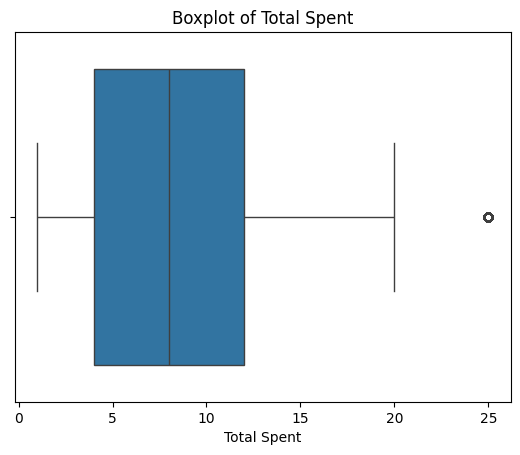

In [13]:
# Convert important columns to numeric
df["Quantity"] = pd.to_numeric(df["Quantity"], errors='coerce')
df["Price Per Unit"] = pd.to_numeric(df["Price Per Unit"], errors='coerce')
df["Total Spent"] = pd.to_numeric(df["Total Spent"], errors='coerce')

col = "Total Spent"

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

print(f"\nOutliers in {col}:")
print(outliers)

# Boxplot
plt.figure()
sns.boxplot(x=df[col])
plt.title(f"Boxplot of {col}")
plt.show()